In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# importing data
df = pd.read_csv('/content/netflix_titles.csv')

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [9]:
df.shape

(8807, 12)

In [10]:
# handling Missing Values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Not Available', inplace=True)
df['country'].fillna('Unknown', inplace=True)

df.dropna(subset=['rating', 'date_added', 'duration'], inplace=True)

/tmp/ipython-input-10-3908446493.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipython-input-10-3908446493.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [12]:
df.shape

(8790, 12)

#### "Analyzing global content trends on Netflix by exploring the distribution, types, release patterns, and regional availability of movies and TV shows, with the goal of uncovering viewer content preferences and production trends over time."



/tmp/ipython-input-14-4084900112.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


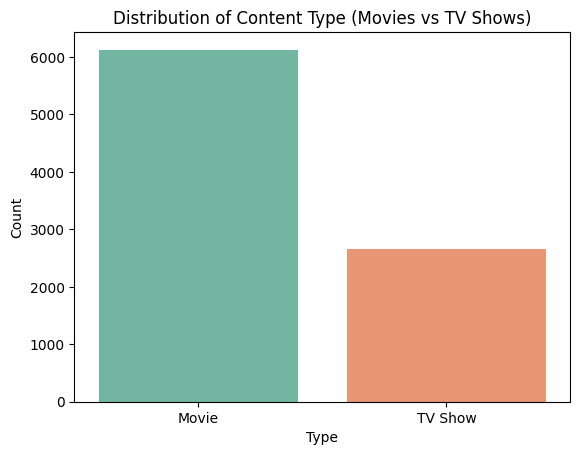

In [14]:
sns.countplot(data=df, x='type', palette='Set2')
plt.title("Distribution of Content Type (Movies vs TV Shows)")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

Conclusion:

Soo we have more number of movies then TV show in dataset.

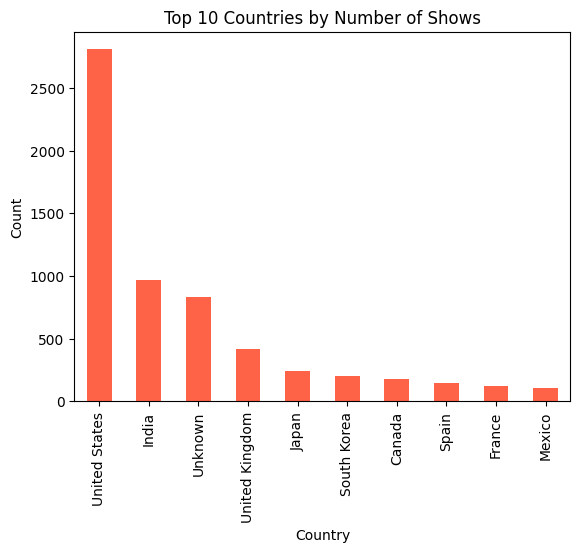

In [16]:
# ---- Top 10 countries producing netflix content ----
top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind='bar', color='tomato')
plt.title("Top 10 Countries by Number of Shows")
plt.ylabel("Count")
plt.xlabel("Country")
plt.xticks(rotation=90)
plt.show()

Conclusion:

From given plot we can figure out top countries producing the netflix content we can see those countries are united States , India , United kingdom etc .

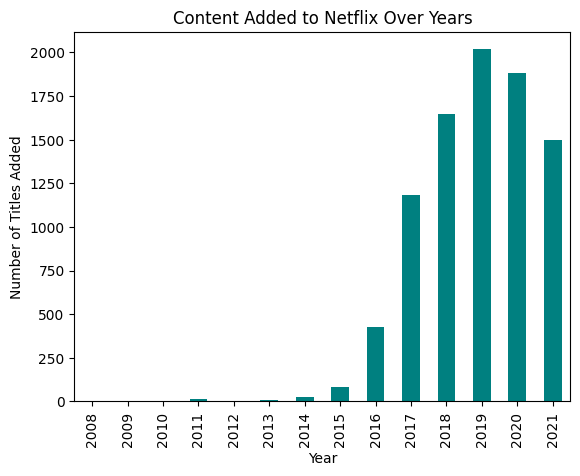

In [19]:
df['date_added_fixed'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')
df['year_added'] = df['date_added_fixed'].dt.year

df['year_added'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title("Content Added to Netflix Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()


Conclusion:

The given plot shows Content Added Over Time soo we can see most of contented was added in 2018 - 2020.

In [20]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_added_fixed,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021-09-25,2021
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021-09-24,2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021-09-24,2021
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021-09-24,2021
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021-09-24,2021


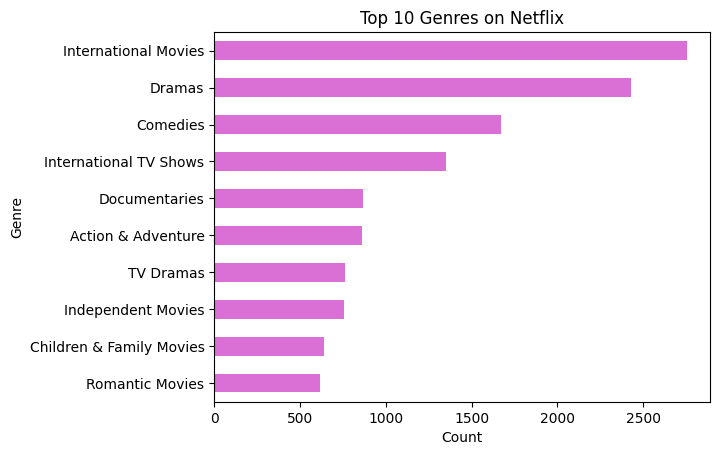

In [22]:
# ---- Top 10 Genres/Listed_in ---
from collections import Counter

# Split multiple genres
all_genres = df['listed_in'].str.split(', ').sum()
top_genres = pd.Series(Counter(all_genres)).sort_values(ascending=False).head(10)

top_genres.plot(kind='barh', color='orchid')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.gca().invert_yaxis()
plt.show()

Conclusion:

The given horizontal bar graph shows the top 10 genre on netflix .

Here we use counter bcoz every movie or show has more then one genre so we need to split and count each .

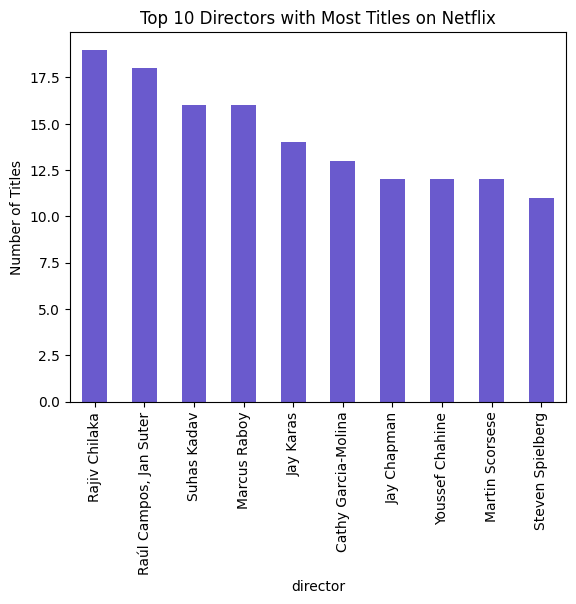

In [24]:
# --- Top 10 Directors ---
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)
top_directors.plot(kind='bar', color='slateblue')
plt.title("Top 10 Directors with Most Titles on Netflix")
plt.ylabel("Number of Titles")
plt.xticks(rotation=90)
plt.show()

Conclusion:

The above plot shows the top 10 directors .

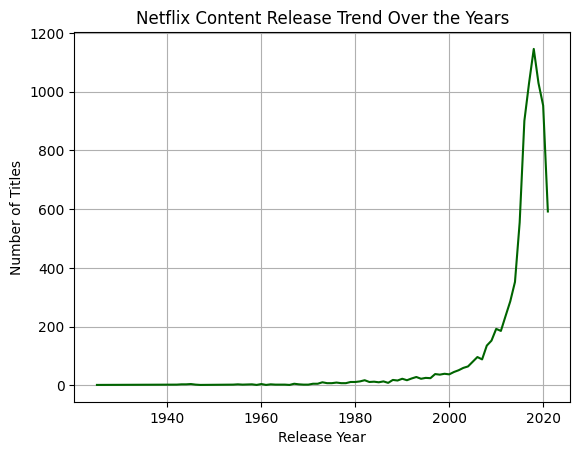

In [25]:
# --- Release Year Trend -----
df['release_year'].value_counts().sort_index().plot(kind='line', color='darkgreen')
plt.title("Netflix Content Release Trend Over the Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

Conclusion:

The above line graph shows the trend of release over years which we can clearly see increasing over years but we can see drastic change from 2000 to 2020 and then there is fall in the trend after 2020.

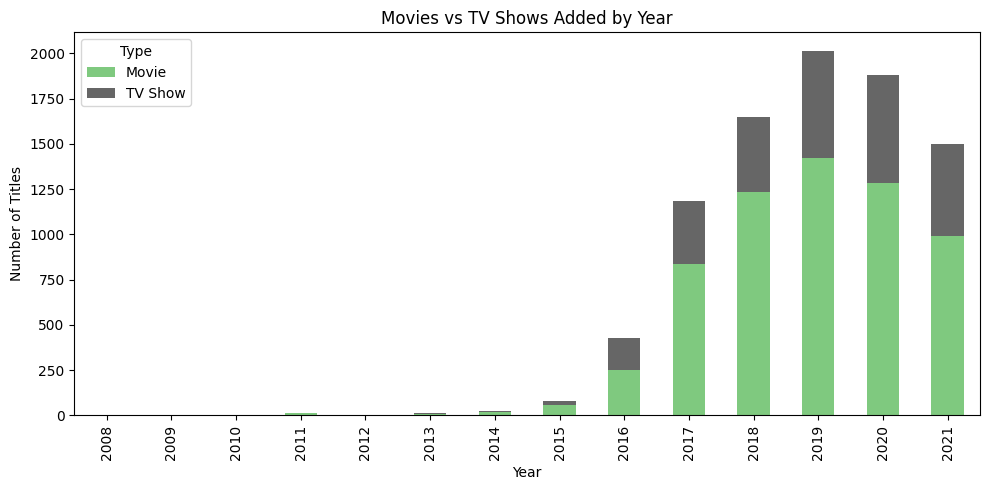

In [27]:
# ---- Movies vs TV Shows by Year ---
content_type_year = df.groupby(['year_added', 'type']).size().unstack().fillna(0)

content_type_year.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Accent')
plt.title("Movies vs TV Shows Added by Year")
plt.ylabel("Number of Titles")
plt.xlabel("Year")
plt.xticks(rotation=90)
plt.legend(title="Type")
plt.tight_layout()
plt.show()

Conclusion:

The given Stacked bar chart Shows the trend of content type being added over the years.

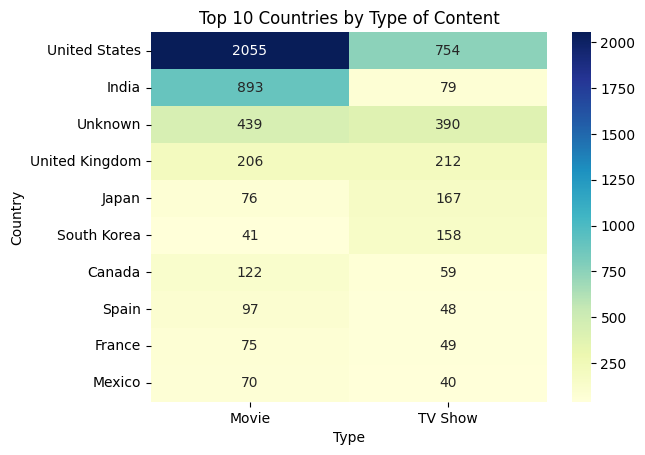

In [28]:
# ---- Heatmap of Content by Country and Type ----
country_type = df.groupby(['country', 'type']).size().unstack().fillna(0)
top_countries = country_type.sum(axis=1).sort_values(ascending=False).head(10)
sns.heatmap(country_type.loc[top_countries.index], annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("Top 10 Countries by Type of Content")
plt.ylabel("Country")
plt.xlabel("Type")
plt.show()

Conclusion:

The given heatmap shows Which countries produce more movies or shows. The numbers in each box shows the number of movies or tv show produced by each country.

/tmp/ipython-input-29-420772790.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_df['duration_mins'] = movies_df['duration'].str.extract('(\d+)').astype(float)


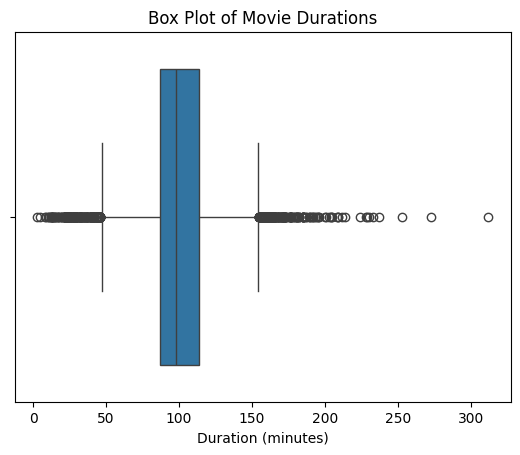

In [29]:
# --- Box Plot of Duration (Movies Only) ---
movies_df = df[df['type'] == 'Movie']
movies_df['duration_mins'] = movies_df['duration'].str.extract('(\d+)').astype(float)

sns.boxplot(x=movies_df['duration_mins'])
plt.title("Box Plot of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.show()

Conclusion:

The given box plot is for movies over duration and we can find many outliers.

/tmp/ipython-input-31-790860596.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tvshow_df['duration_mins'] = tvshow_df['duration'].str.extract('(\d+)').astype(float)


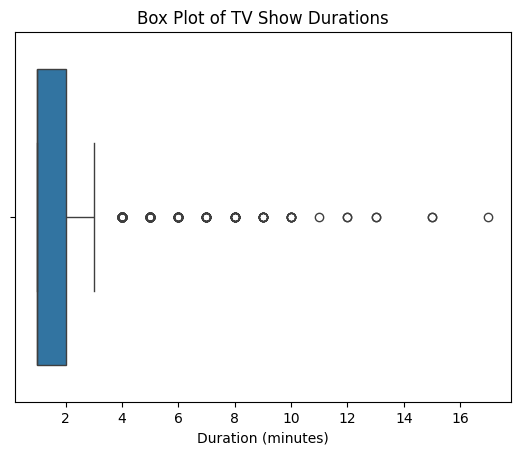

In [31]:
# ---  Box Plot of Duration (TV Show only) ---
tvshow_df = df[df['type'] == 'TV Show']
# Assign the new column to tvshow_df, not movies_df
tvshow_df['duration_mins'] = tvshow_df['duration'].str.extract('(\d+)').astype(float)

sns.boxplot(x=tvshow_df['duration_mins'])
plt.title("Box Plot of TV Show Durations")
plt.xlabel("Duration (minutes)")
plt.show()

Conclusion:

We dont see much outliers for TV Show.

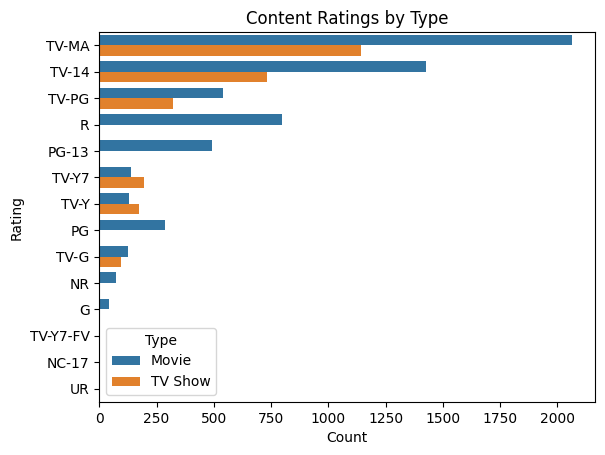

In [32]:
# ----  Rating Distribution by Content Type ----
sns.countplot(data=df, y='rating', hue='type', order=df['rating'].value_counts().index)
plt.title("Content Ratings by Type")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.legend(title="Type")
plt.show()

Conclusion:

The given count plot helps to figure out Are certain ratings more common for movies vs shows.

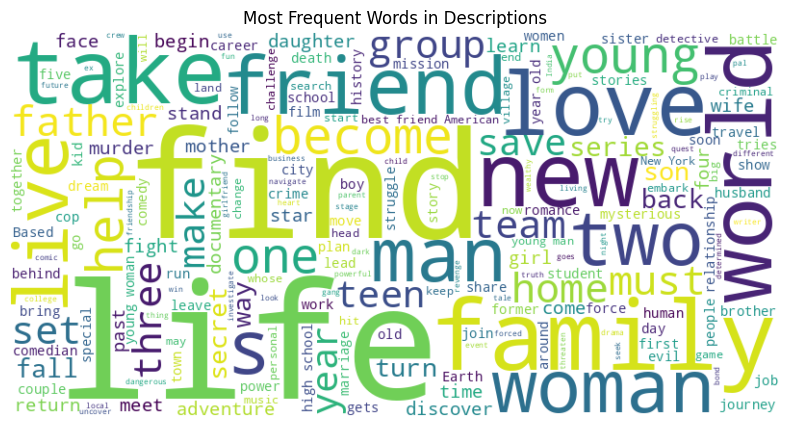

In [33]:
# ---- Top 10 Common Words in Descriptions (Word Cloud) ----
from wordcloud import WordCloud

text = " ".join(df['description'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Descriptions")
plt.show()

Conclusion:

The given word cloud shows the most common words used in description.

#### Modeling Problem Statement
Predict whether a Netflix title is a Movie or a TV Show based on available metadata such as description, country, rating, genres, etc.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [35]:
# Clean data
df_model = df[['type', 'description', 'listed_in', 'country', 'rating', 'release_year']].dropna()

In [36]:
# Encode target
le = LabelEncoder()
df_model['type_encoded'] = le.fit_transform(df_model['type'])

In [37]:
# Features and target
X = df_model[['description', 'listed_in', 'country', 'rating', 'release_year']]
y = df_model['type_encoded']

In [38]:
# ColumnTransformer for processing
preprocessor = ColumnTransformer(
    transformers=[
        ('desc_tfidf', TfidfVectorizer(max_features=300), 'description'),
        ('genre_tfidf', TfidfVectorizer(max_features=100), 'listed_in'),
        ('country_ohe', OneHotEncoder(handle_unknown='ignore'), ['country']),
        ('rating_ohe', OneHotEncoder(handle_unknown='ignore'), ['rating']),
        ('pass_year', 'passthrough', ['release_year'])
    ])

In [39]:
# Create pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [40]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
# Train model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('desc_tfidf',
                                                  TfidfVectorizer(max_features=300),
                                                  'description'),
                                                 ('genre_tfidf',
                                                  TfidfVectorizer(max_features=100),
                                                  'listed_in'),
                                                 ('country_ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['country']),
                                                 ('rating_ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['rating']),
                                                 ('pass_year', 'passthrough',
                                                  ['release_year'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [42]:
# Predict and evaluate
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1227
     TV Show       1.00      1.00      1.00       531

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758

